In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Setup functions

In [2]:
def calculate_ces_utility(allocation, valuations, m):
    """
    Calculates CES utility for users based on the formula:
    U_i(x_i) = (sum_j (v_ij * x_ij)^m)^(1/m)

    Parameters:
    - allocation: (n, k) matrix of allocated goods
    - valuations: (n, k) matrix of linear valuations weights
    - m: exponent parameter. Can be an integer/float or 'inf'.
      If m='inf', calculates U_i(x_i) = max_j (v_ij * x_ij)

    Returns:
    - (n,) array of utility values for each user.
    """
    # Element-wise product: value derived from each item
    # shape: (n, k)
    product = valuations * allocation

    if m == 'inf':
        # Limit case: Max over items
        return np.max(product, axis=1)
    else:
        # Standard CES form
        # We handle potential negative values by taking abs, though in this context x and v are usually non-negative.
        # Using np.power with m
        sum_pow = np.sum(np.power(product, m), axis=1)
        return np.power(sum_pow, 1/m)

def loose_envy_freeness_ces(allocation, valuations, m=1, epsilon=0, return_relative_envy=False):
    """
    Checks Loose Envy Freeness condition using CES utility.
    User i envies User j if U_i(A_j) > U_i(A_i) + epsilon.

    Parameters:
    - allocation: (n, k) matrix of allocated goods
    - valuations: (n, k) matrix of linear valuations weights
    - m: exponent parameter for CES utility. Can be an integer/float or 'inf'.
    - epsilon: tolerance for envy check. U_i(A_j) > U_i(A_i) + epsilon.
    - return_relative_envy: If True, max_user_envy will be (Max_j U_i(A_j) - U_i(A_i)) / U_i(A_i).
                            Otherwise, it returns the absolute difference.

    Returns:
    - satisfaction_pct: Percentage of users who do not envy anyone (max_envy <= epsilon)
    - max_user_envy: List of max envy values for each user.
                     If return_relative_envy is True, Value = (Max_j U_i(A_j) - U_i(A_i)) / U_i(A_i)
                     Else, Value = (Max_j U_i(A_j) - U_i(A_i))
    """
    n = len(allocation)
    satisfied_count = 0
    max_user_envy = []

    # Calculate utilities of each user for their own bundle
    # U_own[i] = U_i(A_i)
    u_own = calculate_ces_utility(allocation, valuations, m)

    for i in range(n):
        # Calculate utility of user i for EVERYONE's bundle
        # We tile user i's valuation to match the shape of allocation matrix
        val_i_matrix = np.tile(valuations[i], (n, 1))

        # U_i_all[j] = U_i(A_j)
        u_i_all = calculate_ces_utility(allocation, val_i_matrix, m)

        # Calculate Envy: U_i(A_j) - U_i(A_i)
        # We look for the MAXIMUM envy user i has towards anyone
        envy_values = u_i_all - u_own[i]
        max_envy = np.max(envy_values)

        # Check satisfaction (no envy greater than epsilon)
        if max_envy <= epsilon:
            satisfied_count += 1

        if return_relative_envy:
            if u_own[i] > 0:
                max_user_envy.append(max_envy / u_own[i])
            else:
                # If own utility is 0, relative envy is ill-defined or infinite if max_envy > 0.
                # For practical purposes, we can consider it 0 if max_envy <= 0, else a large number or 0.
                max_user_envy.append(0.0) # Or handle as np.inf if max_envy > 0
        else:
            max_user_envy.append(max_envy)

    return (satisfied_count / n) * 100, max_user_envy

def proportional_fairness_ces(allocation, valuations, budgets, m=1, epsilon=0, total_resources=None, return_relative_envy=False):
    """
    Checks Proportional Fairness using CES utility.
    Condition: U_i(A_i) >= (B_i / Total_Budget) * U_i(Total_Resources)

    Returns:
    - satisfaction_pct: % of users satisfying the condition
    - proportionality_gap: List of gaps (U_i(A_i) - Required_Share)
    """
    n = len(allocation)
    budgets = np.array(budgets, dtype=float)
    total_budget = np.sum(budgets)

    # If total resources not provided, sum the current allocation
    if total_resources is None:
        total_resources = np.sum(allocation, axis=0)

    # Calculate U_i(Total_Resources) for each user
    # We tile total_resources to evaluate it against every user's valuation
    total_alloc_matrix = np.tile(total_resources, (n, 1))
    u_all_goods = calculate_ces_utility(total_alloc_matrix, valuations, m)

    # Calculate U_i(A_i) (Own utility)
    u_own = calculate_ces_utility(allocation, valuations, m)

    satisfied_count = 0
    proportionality_gap = []

    for i in range(n):
        # Proportional share required
        required_utility = (budgets[i] / total_budget) * u_all_goods[i]

        gap = required_utility - u_own[i]

        if return_relative_envy:
            if u_own[i] > 0:
                proportionality_gap.append(gap/u_own[i])
            else:
                proportionality_gap.append(0.0)

        else:
            proportionality_gap.append(gap)

        if gap <= 0:
            satisfied_count += 1

    return (satisfied_count / n) * 100, proportionality_gap

In [3]:
def metrics_histogram(sgd_data, full_data, type="Max User Envy", figsize=(14, 5), bins=20):
    """
    Generates two histograms side-by-side to visualize the frequency distribution
    of Max User Envy values for SGD and Full GD algorithms.

    Parameters:
    - sgd_data (list/np.array): Max envy values for each user from SGD.
    - full_data (list/np.array): Max envy values for each user from Full GD.
    - title (str): Overall title of the figure.
    - figsize (tuple): Size of the figure.
    - bins (int): Number of bins for both histograms.
    """

    sgd_vec = np.array(sgd_data[1], dtype=float)
    full_vec = np.array(full_data[1], dtype=float)

    # Create 1 row and 2 columns for the subplots
    fig, ax = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f"Comparison of Users Gap Satisfaction in Two Methods", fontsize=16) # Overall title

    # --- Left Histogram (ax[0]): SGD Data ---
    ax[0].hist(sgd_vec,
               bins=bins,
               edgecolor='black',
               color='lightcoral',
               alpha=0.8)

    # Highlight the zero envy line (Max Envy > 0 means violation)
    ax[0].axvline(0, color="red", linewidth=2, linestyle="--", label="No Envy Threshold")

    ax[0].set_title(f"SGD {type} Distribution - User Satisfaction {sgd_data[0]:.2f}")
    ax[0].set_xlabel(f"{type} Value")
    ax[0].set_ylabel("Frequency (Number of Users)")
    ax[0].grid(axis='y', linestyle='dotted', alpha=0.6)
    ax[0].legend()

    # --- Right Histogram (ax[1]): Full GD Data ---
    ax[1].hist(full_vec,
               bins=bins,
               edgecolor='black',
               color='skyblue',
               alpha=0.8)

    # Highlight the zero envy line (Max Envy > 0 means violation)
    ax[1].axvline(0, color="red", linewidth=2, linestyle="--", label="No Envy Threshold")

    ax[1].set_title(f"Full GD {type} Distribution - User Satisfaction {full_data[0]:.2f}")
    ax[1].set_xlabel(f"{type} Value")
    ax[1].set_ylabel("Frequency (Number of Users)")
    ax[1].grid(axis='y', linestyle='dotted', alpha=0.6)
    ax[1].legend()

    # Adjust layout to make space for the main title
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Data with 10 users and 24 items

## z-termination conditions

In [9]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"

# --- Code của bạn bắt đầu từ đây ---
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

✓ Đã tải xong factors. Ma trận Valuations có shape: (10, 24)


In [10]:
import pickle
import os # Import os module to handle file paths

original_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data.pkl"
synthetic_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/synthetic_data.pkl"
multiple_budget_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/various_budget_data.pkl"
multiple_energy_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/various_energy_data.pkl"
constrained_A_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/z_termination/original_data_with_constraint_matrix_A.pkl"
users_50_items_60_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/users_50_items_60_data.pkl"
users_300_items_360_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/users_300_items_360_data.pkl"

paths = [original_path, synthetic_path, multiple_budget_path, multiple_energy_path, constrained_A_path]

# Create a dictionary to store the loaded data with meaningful keys
loaded_data_container = {}

for p in paths:
  # Extract a meaningful key name from the path (e.g., 'original_data' from the full path)
  key_name = os.path.splitext(os.path.basename(p))[0]

  # Mở file ở chế độ 'rb' (Read Binary)
  with open(p, 'rb') as f:
      # Dùng pickle.load() để tái tạo lại đối tượng Python và lưu vào dictionary
      loaded_data_container[key_name] = pickle.load(f)
  print("Đã tải dữ liệu thành công!")
  # Truy cập dữ liệu thông qua dictionary và key_name
  print(f"Tổng thời gian chạy SGD (lần trước): {loaded_data_container[key_name]['sgd_run']['alloc_final']}s")

Streaming output truncated to the last 5000 lines.
        3.31718886e-05, 0.00000000e+00, 3.31457979e-05, 3.38969366e-07,
        3.31787455e-05, 3.29958203e-05, 0.00000000e+00, 3.38969366e-07],
       [4.83682851e-05, 4.84401029e-05, 4.84106302e-05, 4.83545637e-05,
        4.80609454e-05, 0.00000000e+00, 4.83000718e-05, 4.85221420e-05,
        4.80201789e-05, 4.86264803e-05, 4.83913210e-05, 4.83821660e-05,
        4.81201915e-05, 4.85008672e-05, 0.00000000e+00, 1.79845284e+00,
        4.82500540e-05, 0.00000000e+00, 4.81791363e-05, 0.00000000e+00,
        4.82474933e-05, 4.86623985e-05, 0.00000000e+00, 0.00000000e+00],
       [1.43875454e-06, 1.43956313e-06, 1.45900975e-06, 1.79918556e+00,
        1.44936519e-06, 0.00000000e+00, 1.45608805e-06, 1.44206346e-06,
        1.44795169e-06, 1.44700627e-06, 1.43759365e-06, 1.43915541e-06,
        1.45277223e-06, 1.44200159e-06, 0.00000000e+00, 1.44818287e-06,
        1.45469722e-06, 0.00000000e+00, 1.45225224e-06, 0.00000000e+00,
        1.4

### Original Data

In [11]:
original_data = loaded_data_container['original_data']

(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()


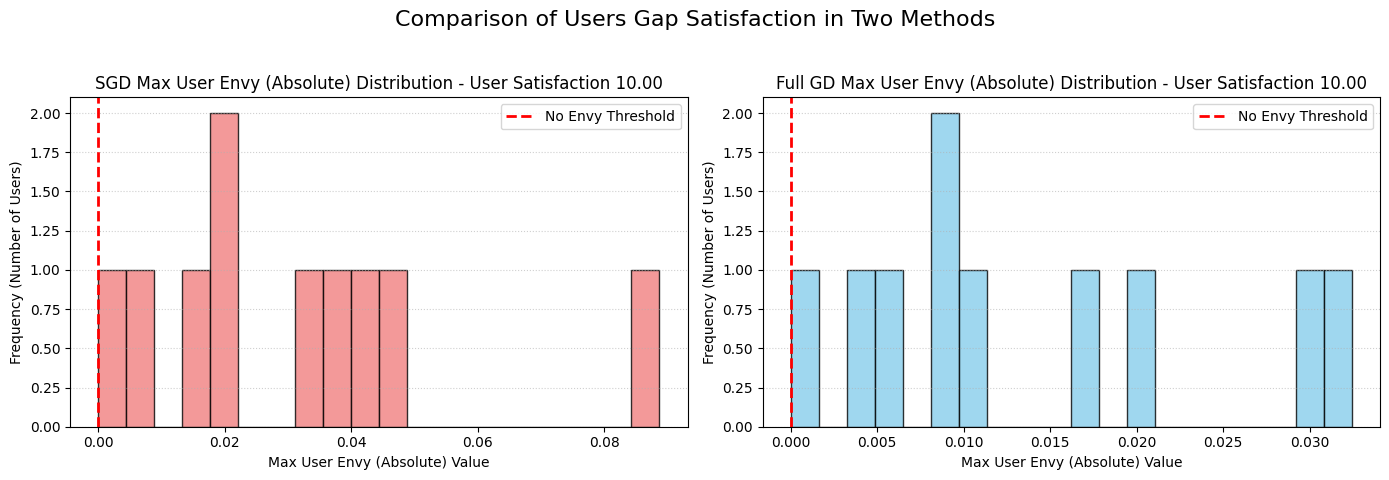

(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()
(10,)
()


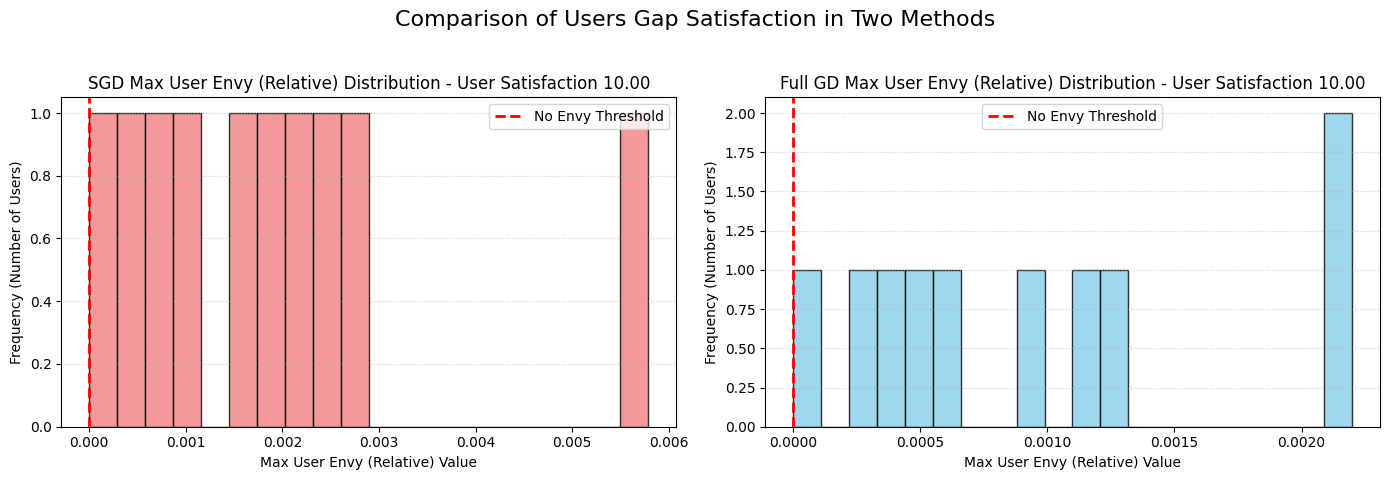

In [12]:
envy_metrics_sgd = loose_envy_freeness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
envy_metrics_full = loose_envy_freeness_ces(original_data["full_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
metrics_histogram(envy_metrics_sgd, envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/original_data_absolute_envy.png")
plt.show()

# Set relative envy = True, divide by each own_utility_i
envy_metrics_sgd_relative = loose_envy_freeness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
envy_metrics_full_relative = loose_envy_freeness_ces(original_data["full_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
metrics_histogram(envy_metrics_sgd_relative, envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/original_data_relative_envy.png")
plt.show()

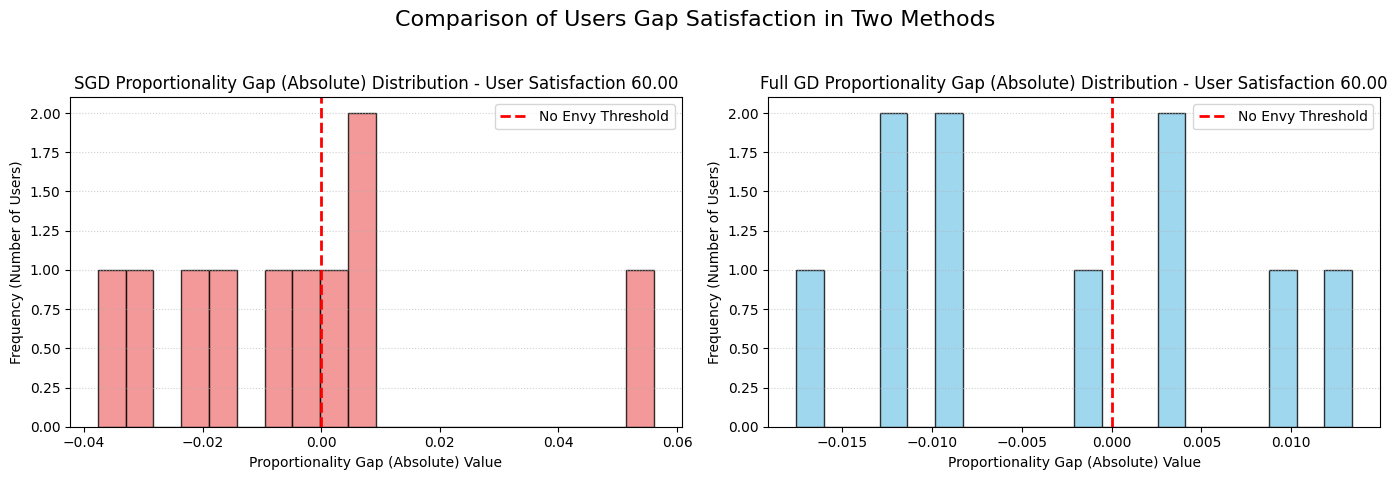

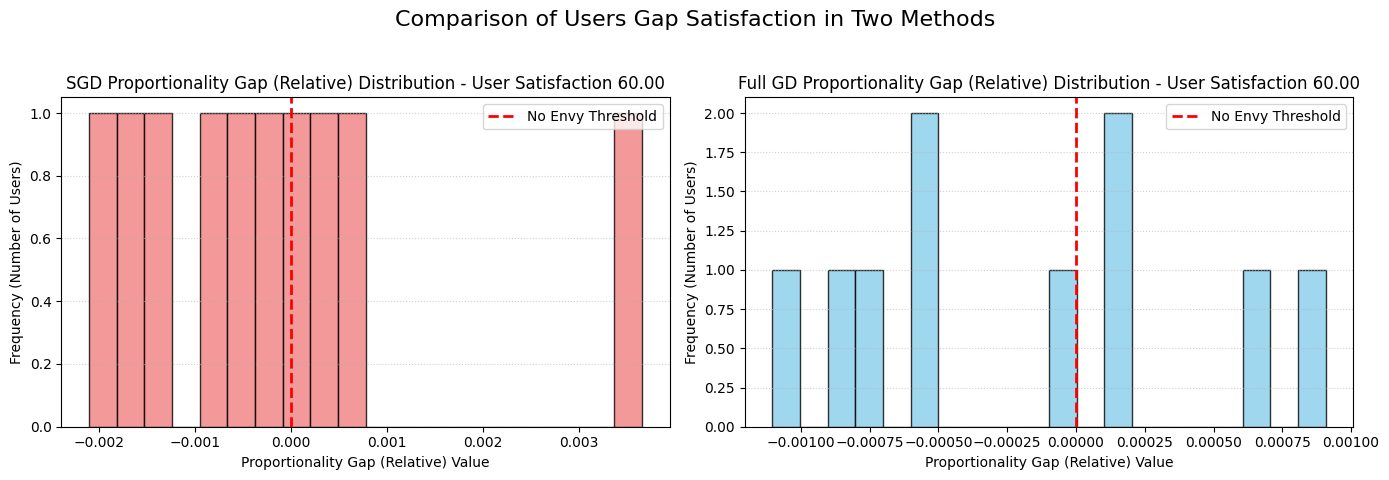

In [ ]:
pro_fair_sgd = proportional_fairness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(original_data["full_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/original_data_absolute_pro.png")
plt.show()

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(original_data["full_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/original_data_relative_pro.png")
plt.show()


### Various Budget

In [ ]:
various_budget_data = loaded_data_container['various_budget_data']

Envy Freeness metrics - User satisfaction (SGD) 10.0
Envy Freeness metrics - User satisfaction (Full GD) 10.0

Envy Freeness metrics - User satisfaction (SGD, Relative Envy) 10.0
Envy Freeness metrics - User satisfaction (Full GD, Relative Envy) 10.0


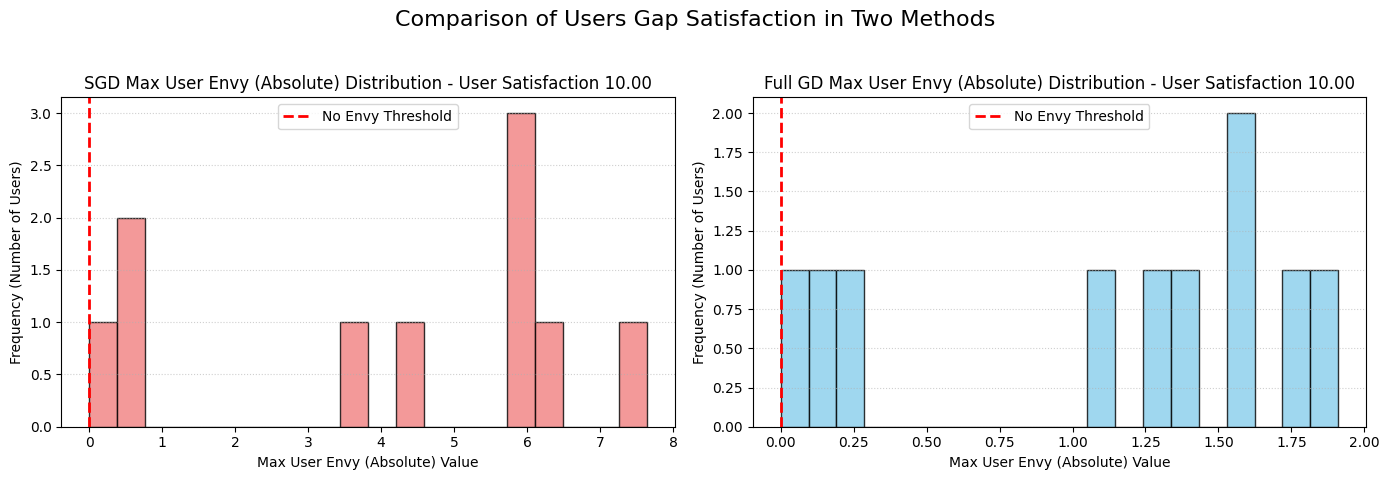

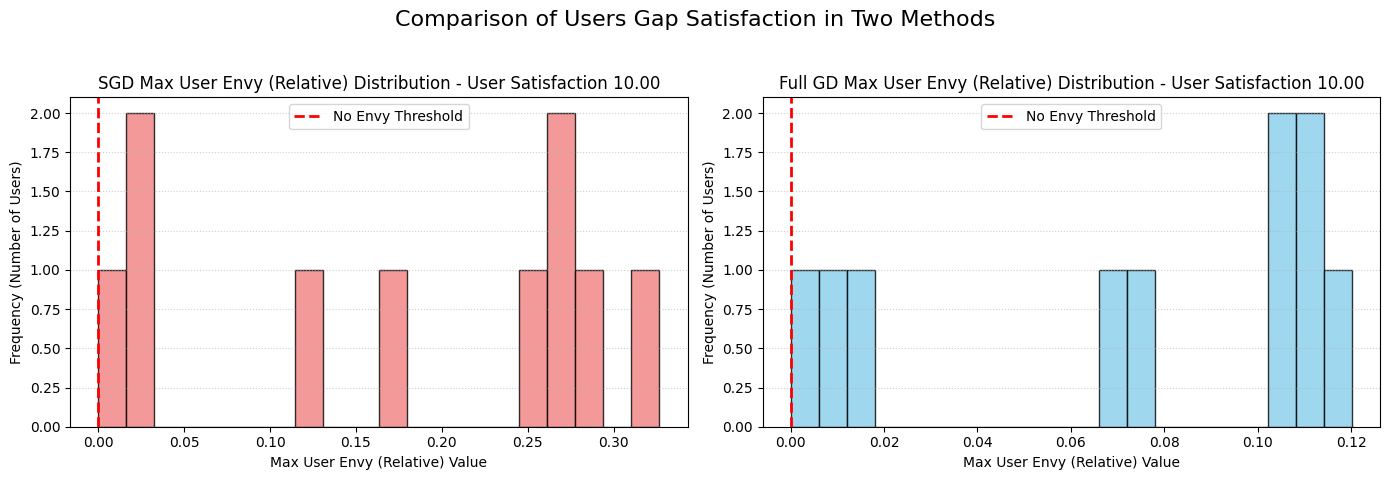

In [ ]:
various_budget_envy_metrics_sgd = loose_envy_freeness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations)
various_budget_envy_metrics_full = loose_envy_freeness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations)
print("Envy Freeness metrics - User satisfaction (SGD)", various_budget_envy_metrics_sgd[0])
print("Envy Freeness metrics - User satisfaction (Full GD)", various_budget_envy_metrics_full[0])
metrics_histogram(various_budget_envy_metrics_sgd, various_budget_envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/various_budget_absolute_envy.png")

# Set relative envy = True, divide by each own_utility_i
various_budget_envy_metrics_sgd_relative = loose_envy_freeness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
various_budget_envy_metrics_full_relative = loose_envy_freeness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
print("\nEnvy Freeness metrics - User satisfaction (SGD, Relative Envy)", various_budget_envy_metrics_sgd_relative[0])
print("Envy Freeness metrics - User satisfaction (Full GD, Relative Envy)", various_budget_envy_metrics_full_relative[0])
metrics_histogram(various_budget_envy_metrics_sgd_relative, various_budget_envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/various_budget_relative_envy.png")

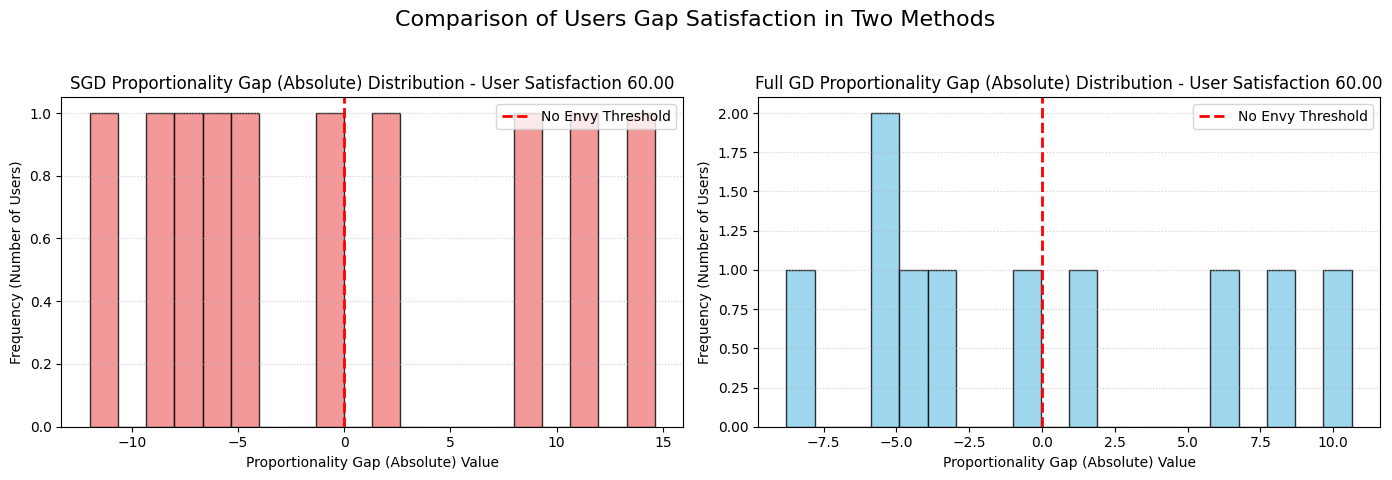

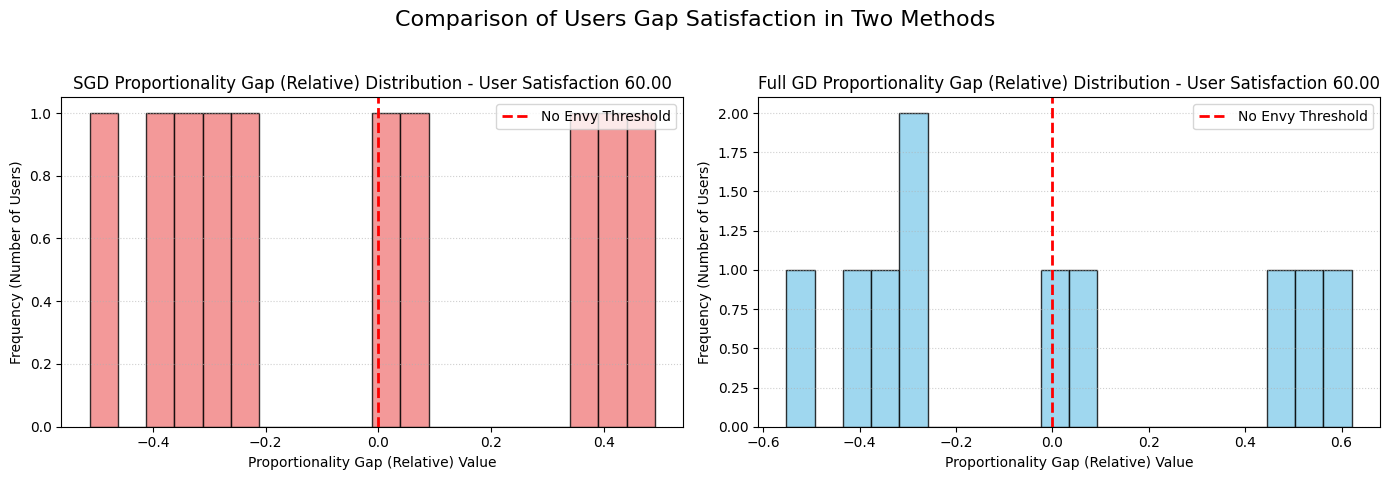

In [ ]:
pro_fair_sgd = proportional_fairness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/various_budget_absolute_pro.png")

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/various_budget_relative_pro.png")

### Constrained A

In [ ]:
constrained_A_data = loaded_data_container['original_data_with_constraint_matrix_A']

Envy Freeness metrics - User satisfaction (SGD) 10.0
Envy Freeness metrics - User satisfaction (Full GD) 10.0

Envy Freeness metrics - User satisfaction (SGD, Relative Envy) 10.0
Envy Freeness metrics - User satisfaction (Full GD, Relative Envy) 10.0


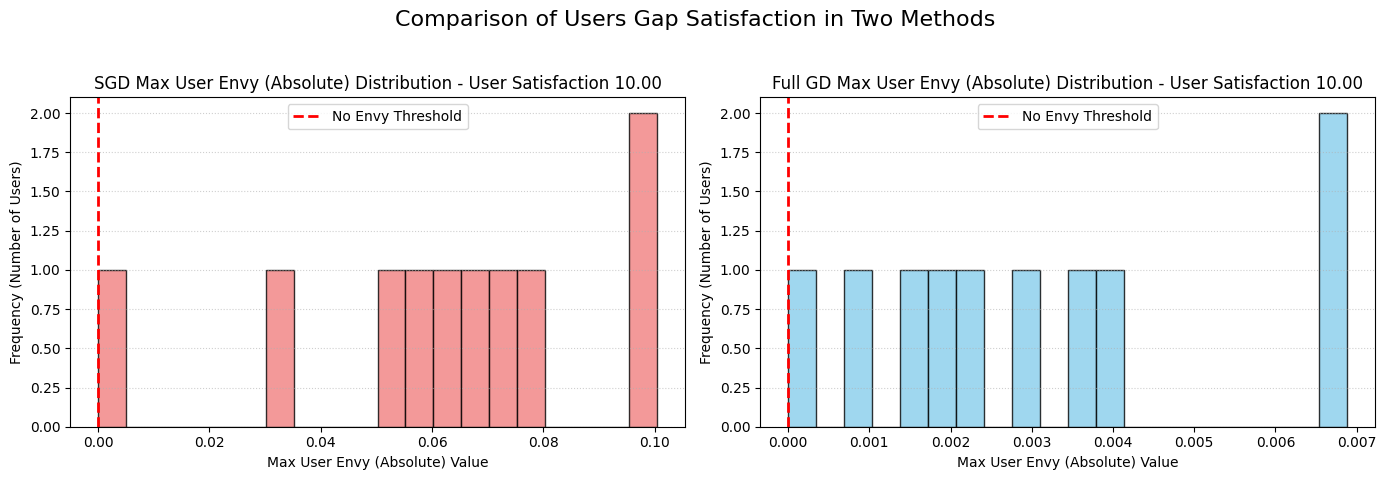

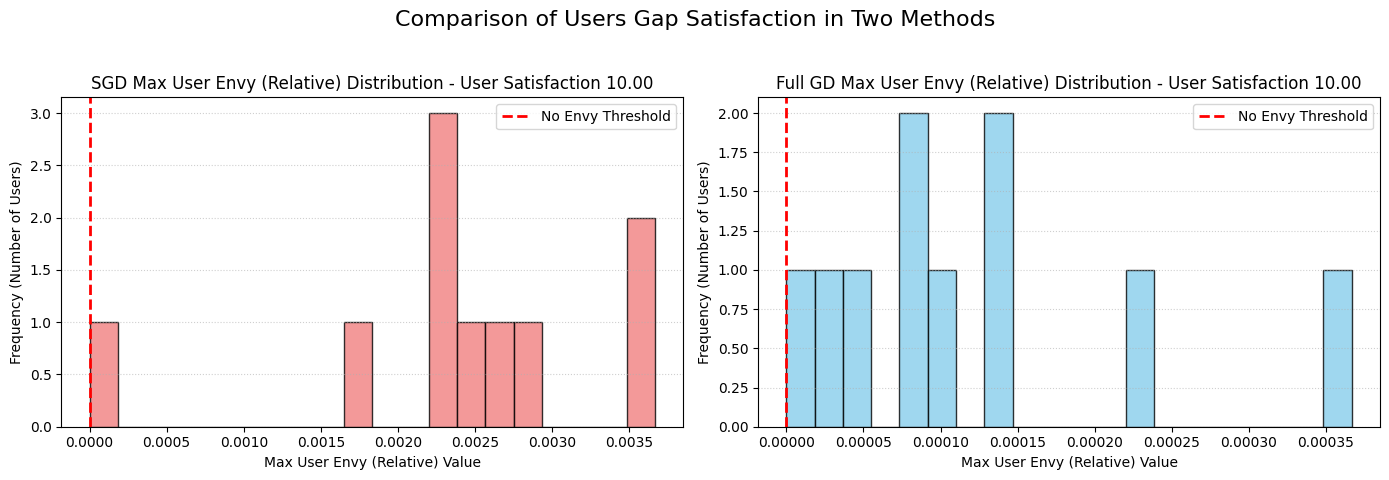

In [ ]:
constrained_A_envy_metrics_sgd = loose_envy_freeness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations)
constrained_A_envy_metrics_full = loose_envy_freeness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations)
print("Envy Freeness metrics - User satisfaction (SGD)", constrained_A_envy_metrics_sgd[0])
print("Envy Freeness metrics - User satisfaction (Full GD)", constrained_A_envy_metrics_full[0])
metrics_histogram(constrained_A_envy_metrics_sgd, constrained_A_envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/constrained_A_absolute_envy.png")

# Set relative envy = True, divide by each own_utility_i
constrained_A_envy_metrics_sgd_relative = loose_envy_freeness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
constrained_A_envy_metrics_full_relative = loose_envy_freeness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
print("\nEnvy Freeness metrics - User satisfaction (SGD, Relative Envy)", constrained_A_envy_metrics_sgd_relative[0])
print("Envy Freeness metrics - User satisfaction (Full GD, Relative Envy)", constrained_A_envy_metrics_full_relative[0])
metrics_histogram(constrained_A_envy_metrics_sgd_relative, constrained_A_envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/constrained_A_relative_envy.png")

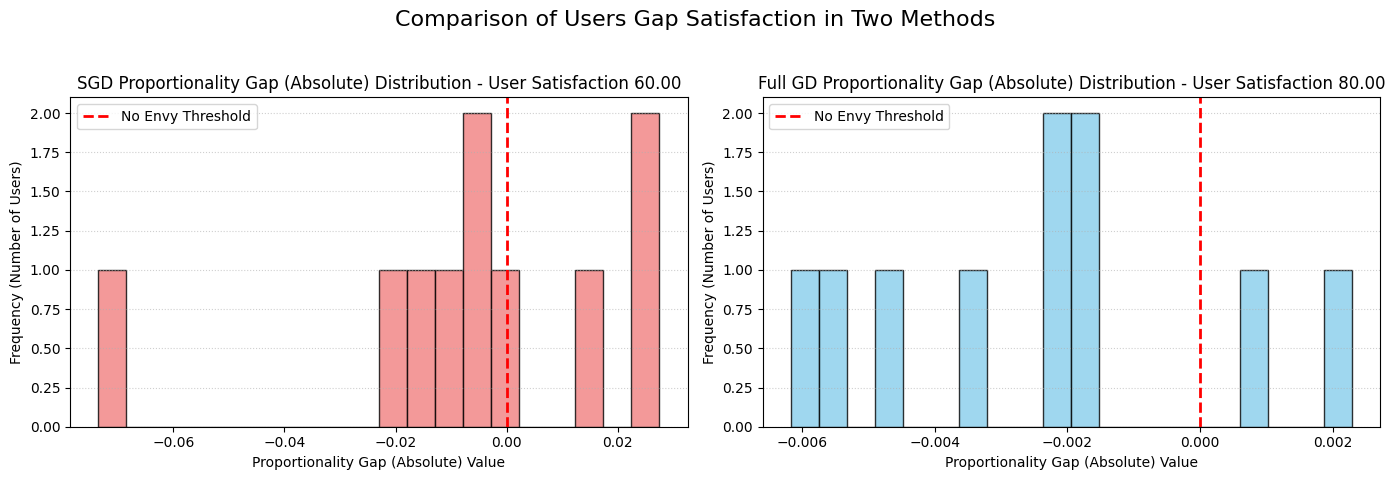

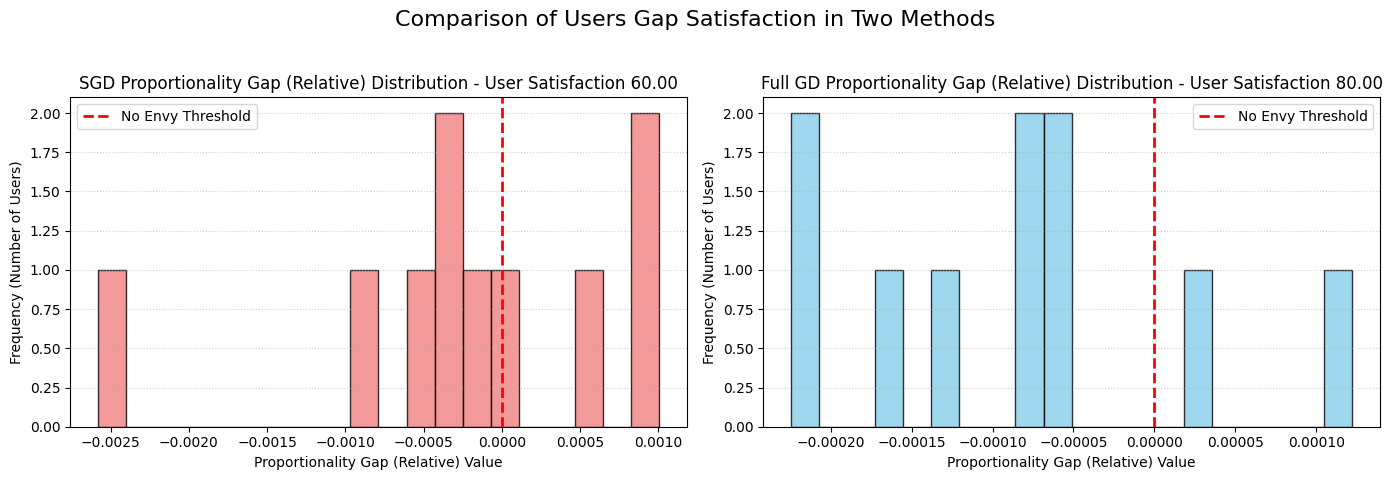

In [ ]:
pro_fair_sgd = proportional_fairness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/constrained_A_absolute_pro.png")

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/z_termination/constrained_A_relative_pro.png")

## Time termination conditions

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_10u_24i"

# --- Code của bạn bắt đầu từ đây ---
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

✓ Đã tải xong factors. Ma trận Valuations có shape: (10, 24)


In [ ]:
import pickle
import os # Import os module to handle file paths

original_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/original_data.pkl"
synthetic_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/synthetic_data.pkl"
multiple_budget_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/various_budget_data.pkl"
multiple_energy_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/various_energy_data.pkl"
constrained_A_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/original_data_with_constraint_matrix_A.pkl"
users_50_items_60_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/users_50_items_60_data.pkl"
users_300_items_360_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/users_300_items_360_data.pkl"

paths = [original_path, synthetic_path, multiple_budget_path, multiple_energy_path, constrained_A_path]

# Create a dictionary to store the loaded data with meaningful keys
loaded_data_container = {}

for p in paths:
  # Extract a meaningful key name from the path (e.g., 'original_data' from the full path)
  key_name = os.path.splitext(os.path.basename(p))[0]

  # Mở file ở chế độ 'rb' (Read Binary)
  with open(p, 'rb') as f:
      # Dùng pickle.load() để tái tạo lại đối tượng Python và lưu vào dictionary
      loaded_data_container[key_name] = pickle.load(f)
  print("Đã tải dữ liệu thành công!")
  # Truy cập dữ liệu thông qua dictionary và key_name
  print(f"Tổng thời gian chạy SGD (lần trước): {loaded_data_container[key_name]['sgd_run']['alloc_final']}s")

Streaming output truncated to the last 5000 lines.
        7.78150202e-01, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 7.15071519e-01, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.08611007e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [5.75198471e-05, 1.79664905e+00, 5.73440780e-05, 5.74326517e-05,
        5.74740039e-05, 1.38336210e-07, 5.73954310e-05, 5.73493870e-05,
        5.72787994e-05, 5.75853520e-05, 5.73760574e-05, 5.73830020e-05,
        5.76351343e-05, 5.74581960e-05, 0.00000000e+00, 5.73055560e-05,
        5.73469299e-05, 1.38336210e-07, 5.73863879e-05, 0.00000000e+00,
        5.7

### Original Data

In [ ]:
original_data = loaded_data_container['original_data']

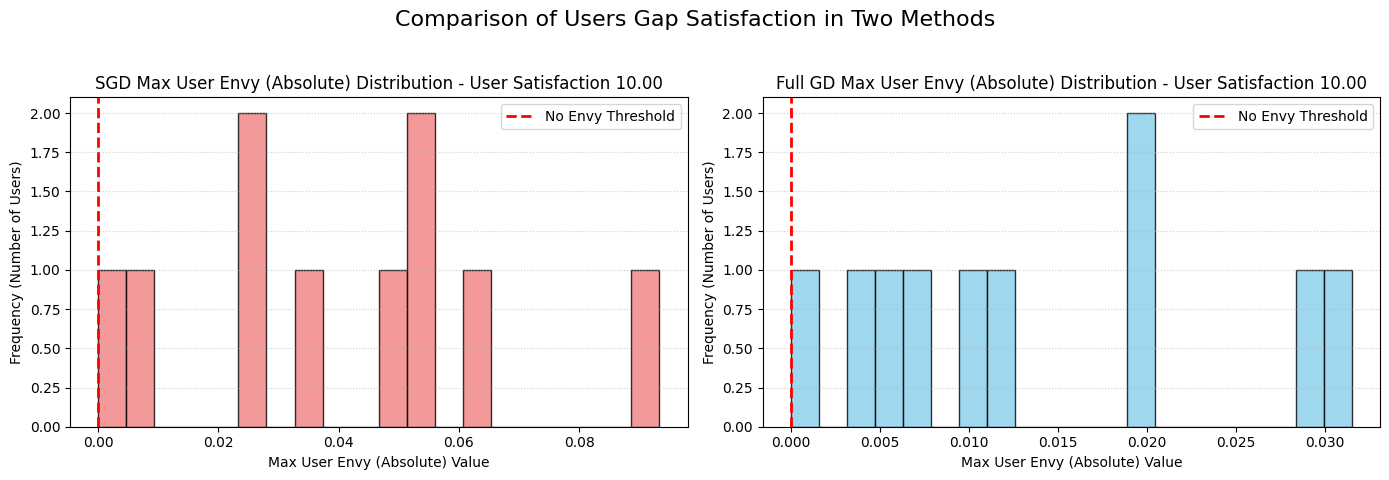

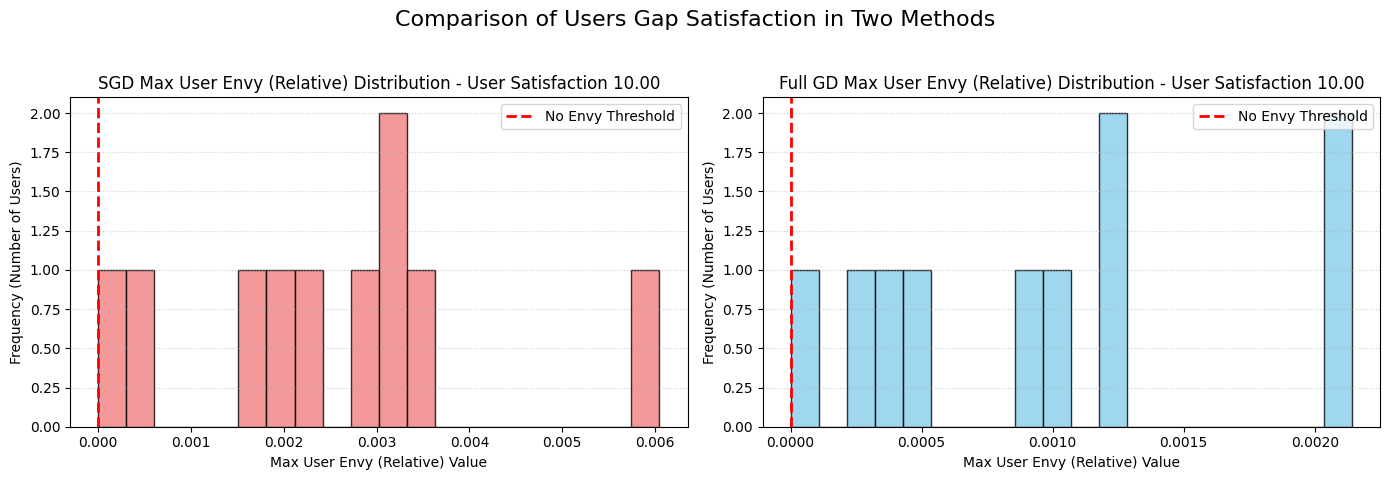

In [ ]:
envy_metrics_sgd = loose_envy_freeness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
envy_metrics_full = loose_envy_freeness_ces(original_data["full_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
metrics_histogram(envy_metrics_sgd, envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/original_data_absolute_envy.png")
plt.show()


# Set relative envy = True, divide by each own_utility_i
envy_metrics_sgd_relative = loose_envy_freeness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
envy_metrics_full_relative = loose_envy_freeness_ces(original_data["full_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
metrics_histogram(envy_metrics_sgd_relative, envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/original_data_relative_envy.png")
plt.show()

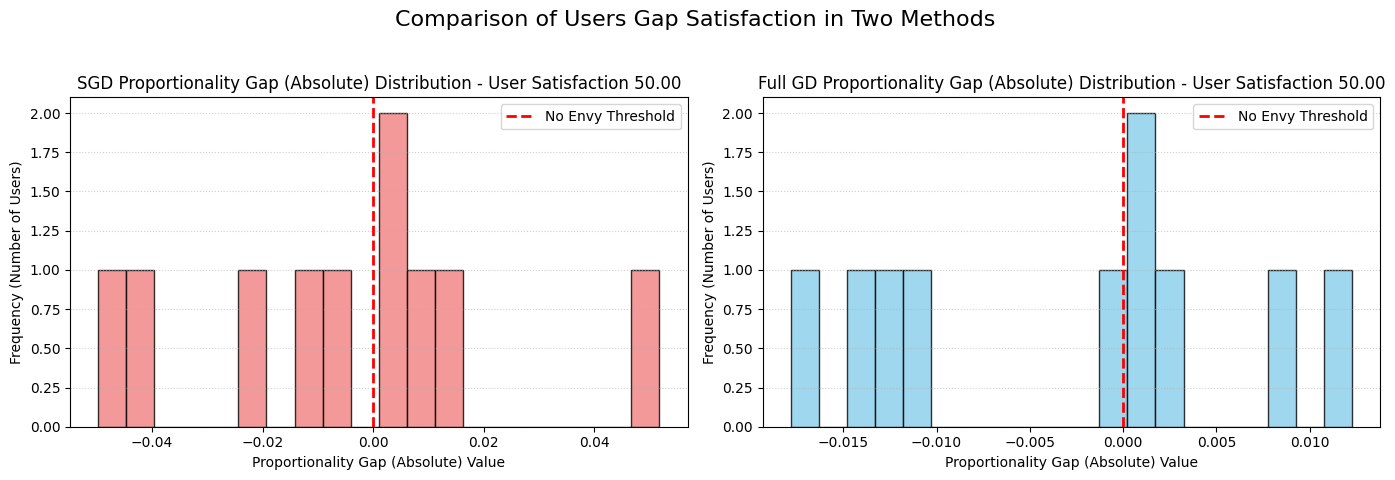

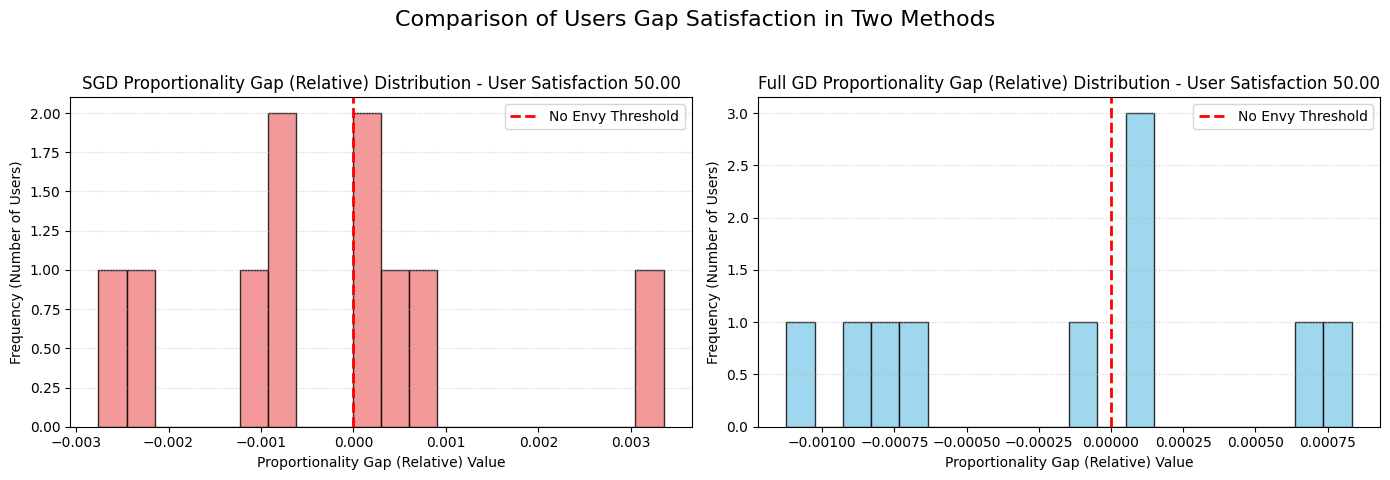

In [ ]:
pro_fair_sgd = proportional_fairness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(original_data["full_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/original_data_absolute_pro.png")
plt.show()

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(original_data["sgd_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(original_data["full_run"]["alloc_final"][-1], valuations, original_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/original_data_relative_pro.png")
plt.show()


### Various Budget

In [ ]:
various_budget_data = loaded_data_container['various_budget_data']

Envy Freeness metrics - User satisfaction (SGD) 10.0
Envy Freeness metrics - User satisfaction (Full GD) 10.0

Envy Freeness metrics - User satisfaction (SGD, Relative Envy) 10.0
Envy Freeness metrics - User satisfaction (Full GD, Relative Envy) 10.0


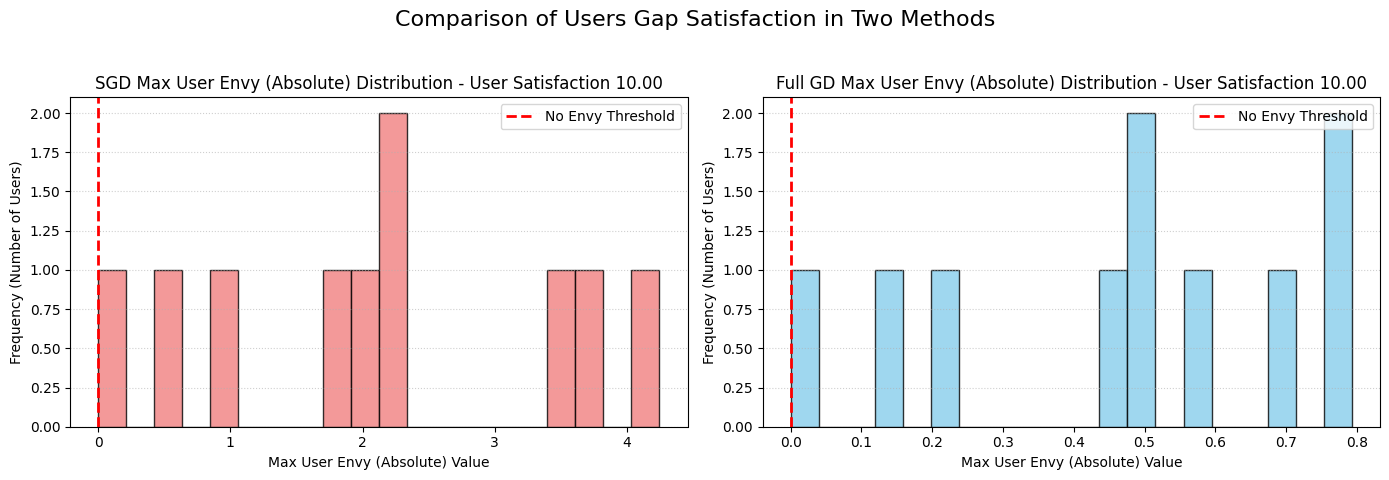

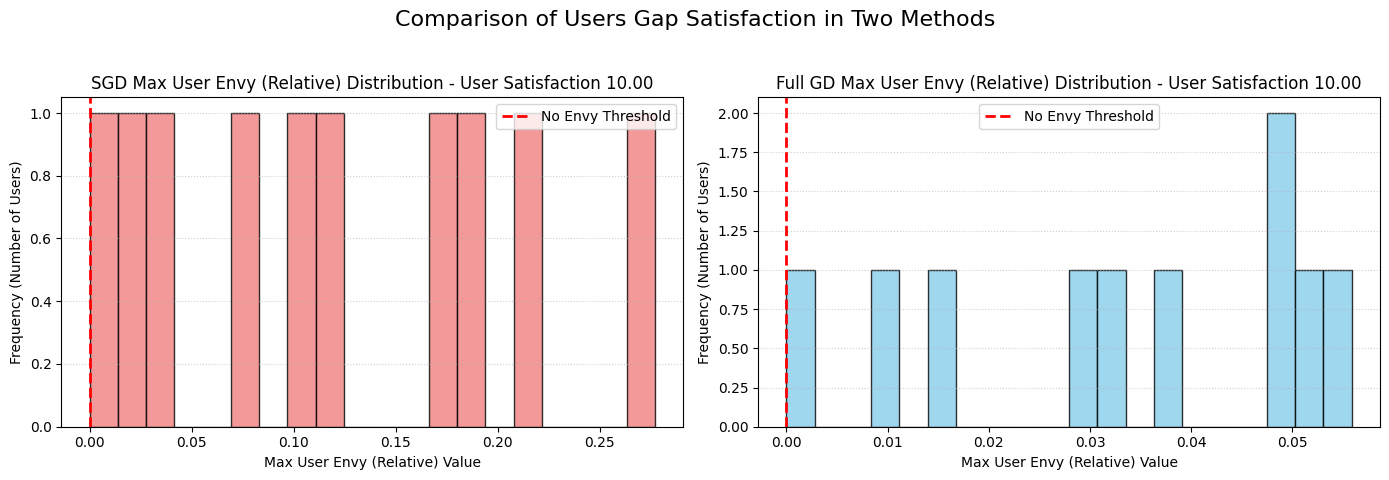

In [ ]:
various_budget_envy_metrics_sgd = loose_envy_freeness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations)
various_budget_envy_metrics_full = loose_envy_freeness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations)
print("Envy Freeness metrics - User satisfaction (SGD)", various_budget_envy_metrics_sgd[0])
print("Envy Freeness metrics - User satisfaction (Full GD)", various_budget_envy_metrics_full[0])
metrics_histogram(various_budget_envy_metrics_sgd, various_budget_envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_budget_absolute_envy.png")

# Set relative envy = True, divide by each own_utility_i
various_budget_envy_metrics_sgd_relative = loose_envy_freeness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
various_budget_envy_metrics_full_relative = loose_envy_freeness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
print("\nEnvy Freeness metrics - User satisfaction (SGD, Relative Envy)", various_budget_envy_metrics_sgd_relative[0])
print("Envy Freeness metrics - User satisfaction (Full GD, Relative Envy)", various_budget_envy_metrics_full_relative[0])
metrics_histogram(various_budget_envy_metrics_sgd_relative, various_budget_envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_budget_relative_envy.png")

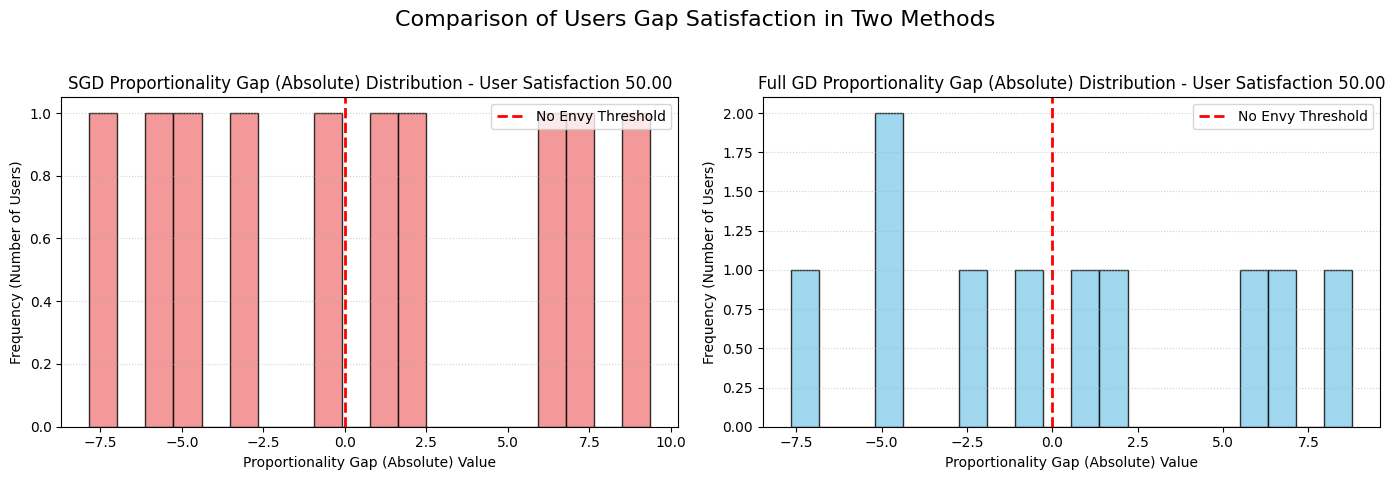

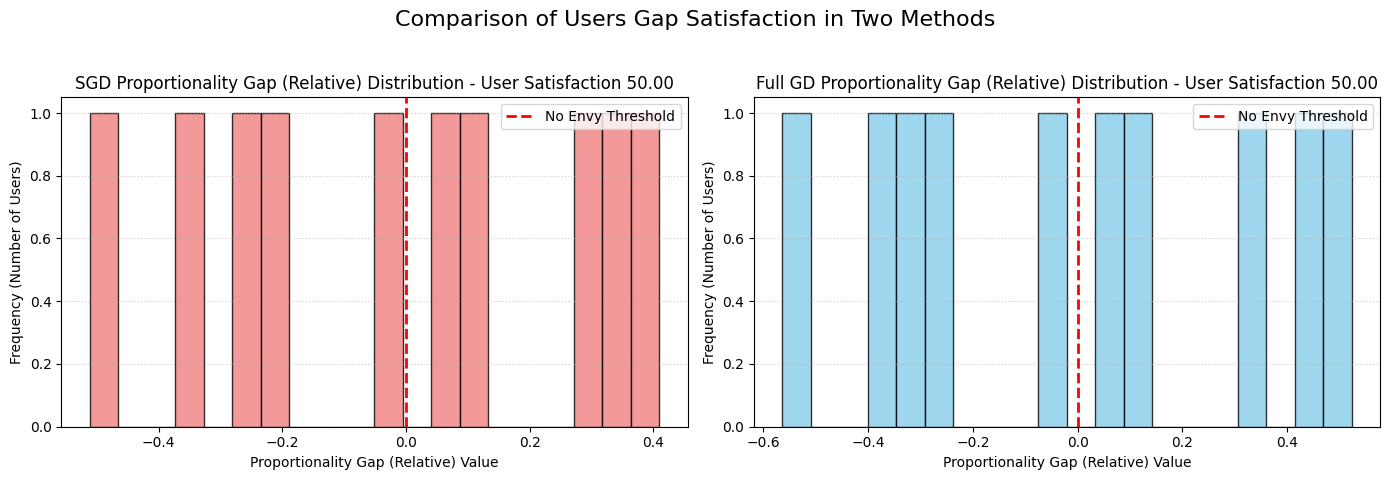

In [ ]:
pro_fair_sgd = proportional_fairness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_budget_absolute_pro.png")

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(various_budget_data["sgd_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(various_budget_data["full_run"]["alloc_final"][-1], valuations, various_budget_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_budget_relative_pro.png")

### Various Energy

In [ ]:
various_energy_data = loaded_data_container['various_energy_data']

Envy Freeness metrics - User satisfaction (SGD) 10.0
Envy Freeness metrics - User satisfaction (Full GD) 20.0

Envy Freeness metrics - User satisfaction (SGD, Relative Envy) 10.0
Envy Freeness metrics - User satisfaction (Full GD, Relative Envy) 20.0


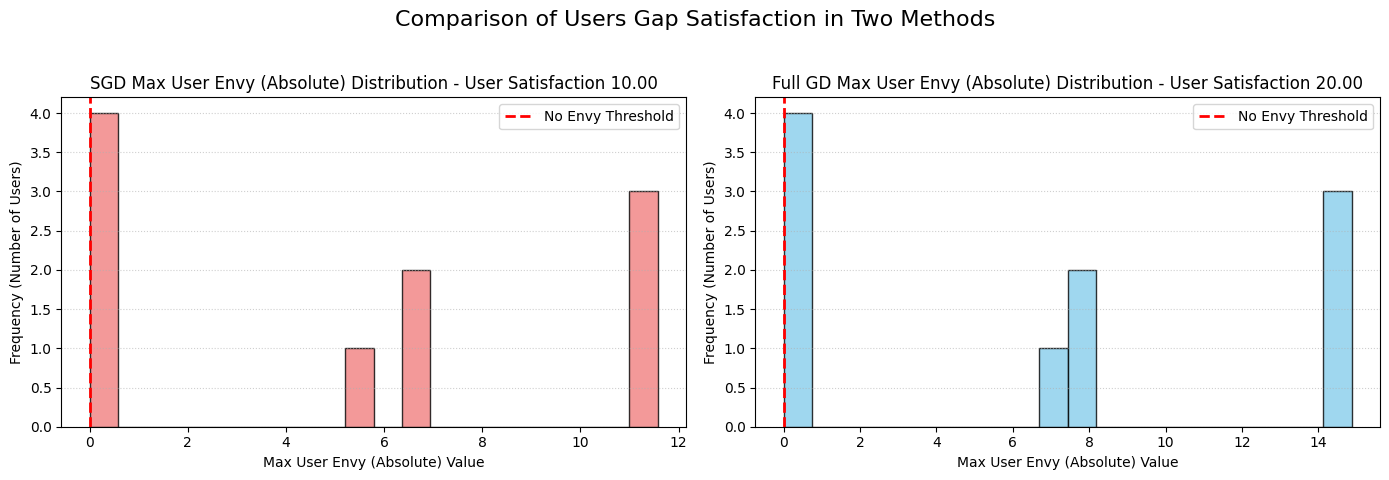

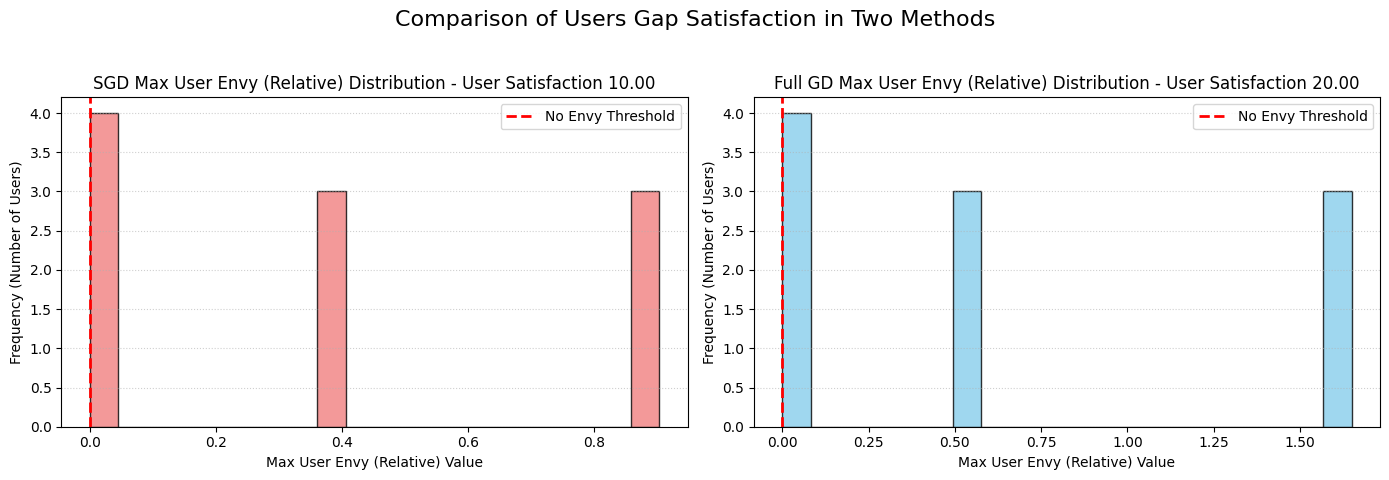

In [ ]:
various_energy_envy_metrics_sgd = loose_envy_freeness_ces(various_energy_data["sgd_run"]["alloc_final"][-1], valuations)
various_energy_envy_metrics_full = loose_envy_freeness_ces(various_energy_data["full_run"]["alloc_final"][-1], valuations)
print("Envy Freeness metrics - User satisfaction (SGD)", various_energy_envy_metrics_sgd[0])
print("Envy Freeness metrics - User satisfaction (Full GD)", various_energy_envy_metrics_full[0])
metrics_histogram(various_energy_envy_metrics_sgd, various_energy_envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_energy_absolute_envy.png")

# Set relative envy = True, divide by each own_utility_i
various_energy_envy_metrics_sgd_relative = loose_envy_freeness_ces(various_energy_data["sgd_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
various_energy_envy_metrics_full_relative = loose_envy_freeness_ces(various_energy_data["full_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
print("\nEnvy Freeness metrics - User satisfaction (SGD, Relative Envy)", various_energy_envy_metrics_sgd_relative[0])
print("Envy Freeness metrics - User satisfaction (Full GD, Relative Envy)", various_energy_envy_metrics_full_relative[0])
metrics_histogram(various_energy_envy_metrics_sgd_relative, various_energy_envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_energy_relative_envy.png")

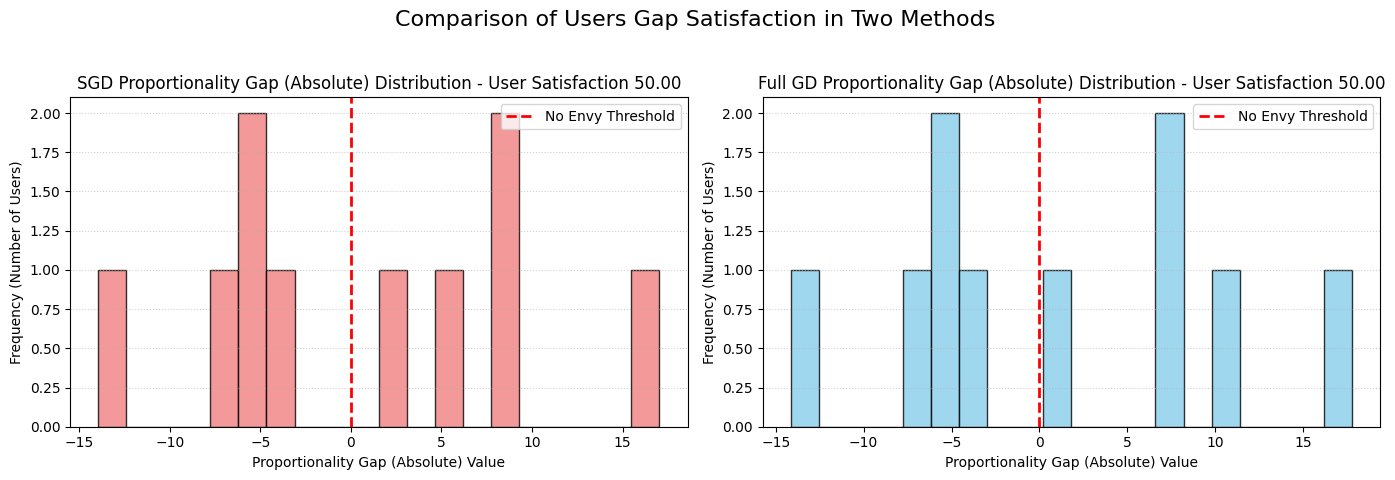

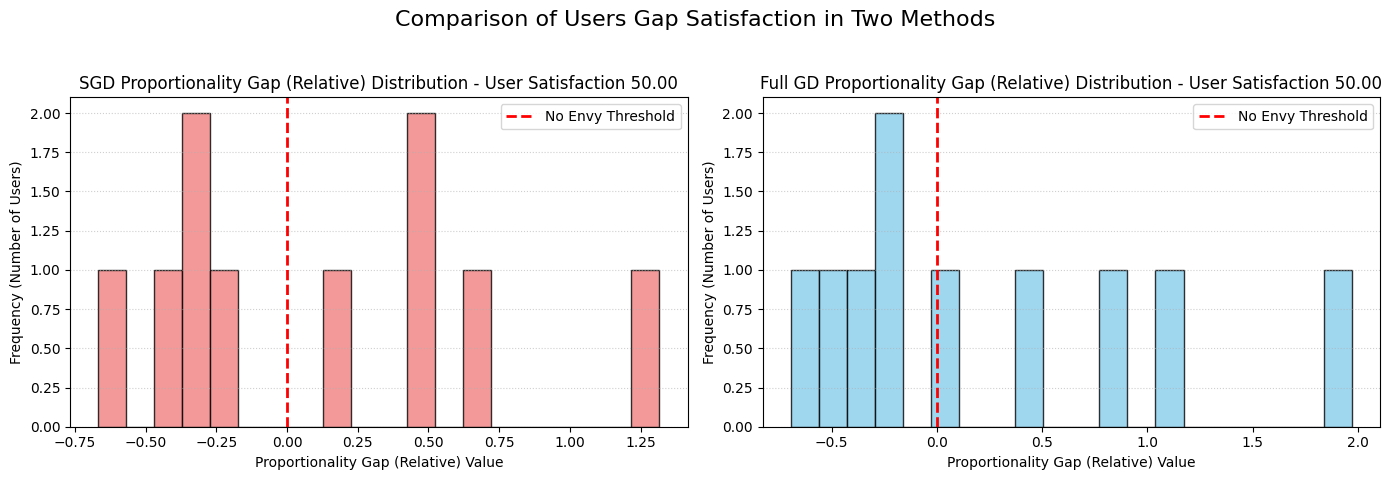

In [ ]:
pro_fair_sgd = proportional_fairness_ces(various_energy_data["sgd_run"]["alloc_final"][-1], valuations, various_energy_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(various_energy_data["full_run"]["alloc_final"][-1], valuations, various_energy_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_energy_absolute_pro.png")

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(various_energy_data["sgd_run"]["alloc_final"][-1], valuations, various_energy_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(various_energy_data["full_run"]["alloc_final"][-1], valuations, various_energy_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/various_energy_relative_pro.png")

### Constrained A

In [ ]:
constrained_A_data = loaded_data_container['original_data_with_constraint_matrix_A']

Envy Freeness metrics - User satisfaction (SGD) 10.0
Envy Freeness metrics - User satisfaction (Full GD) 10.0

Envy Freeness metrics - User satisfaction (SGD, Relative Envy) 10.0
Envy Freeness metrics - User satisfaction (Full GD, Relative Envy) 10.0


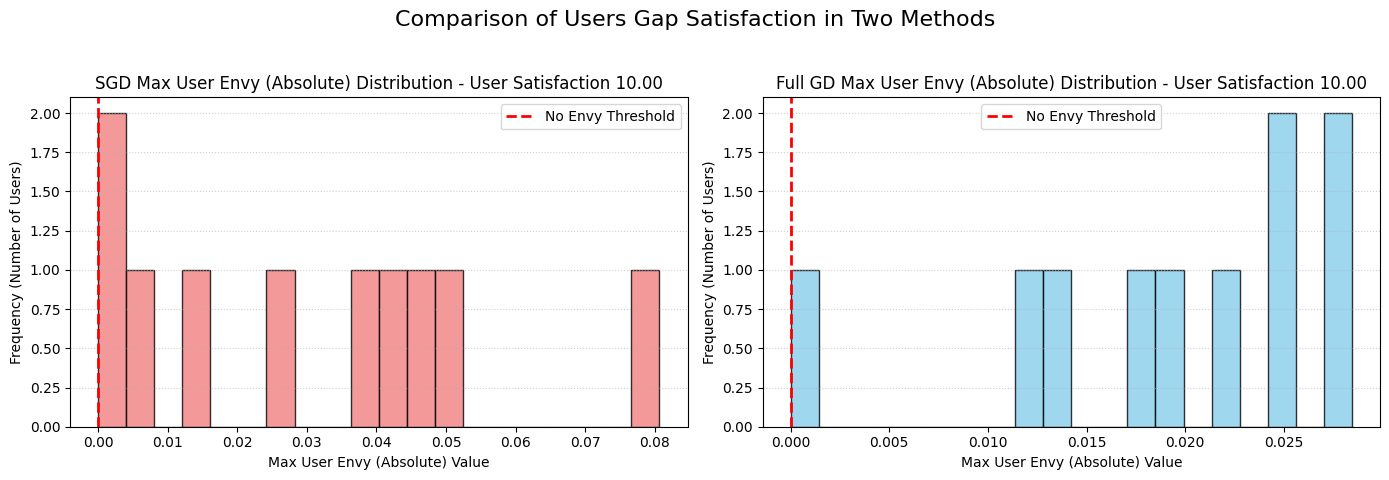

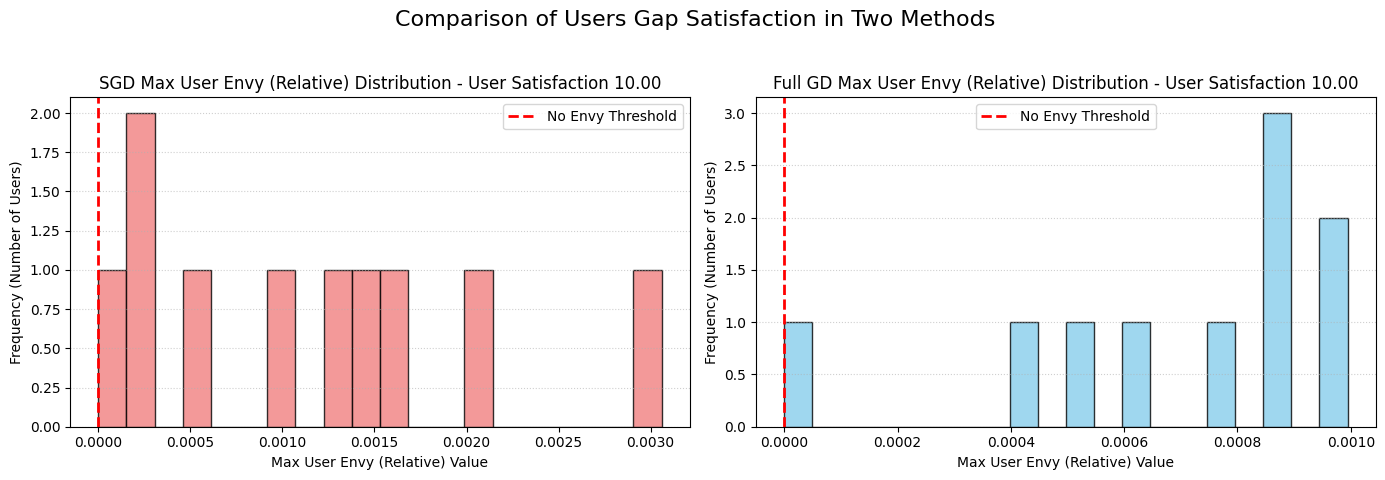

In [ ]:
constrained_A_envy_metrics_sgd = loose_envy_freeness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations)
constrained_A_envy_metrics_full = loose_envy_freeness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations)
print("Envy Freeness metrics - User satisfaction (SGD)", constrained_A_envy_metrics_sgd[0])
print("Envy Freeness metrics - User satisfaction (Full GD)", constrained_A_envy_metrics_full[0])
metrics_histogram(constrained_A_envy_metrics_sgd, constrained_A_envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/constrained_A_absolute_envy.png")

# Set relative envy = True, divide by each own_utility_i
constrained_A_envy_metrics_sgd_relative = loose_envy_freeness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
constrained_A_envy_metrics_full_relative = loose_envy_freeness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations, return_relative_envy=True)
print("\nEnvy Freeness metrics - User satisfaction (SGD, Relative Envy)", constrained_A_envy_metrics_sgd_relative[0])
print("Envy Freeness metrics - User satisfaction (Full GD, Relative Envy)", constrained_A_envy_metrics_full_relative[0])
metrics_histogram(constrained_A_envy_metrics_sgd_relative, constrained_A_envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/constrained_A_relative_envy.png")

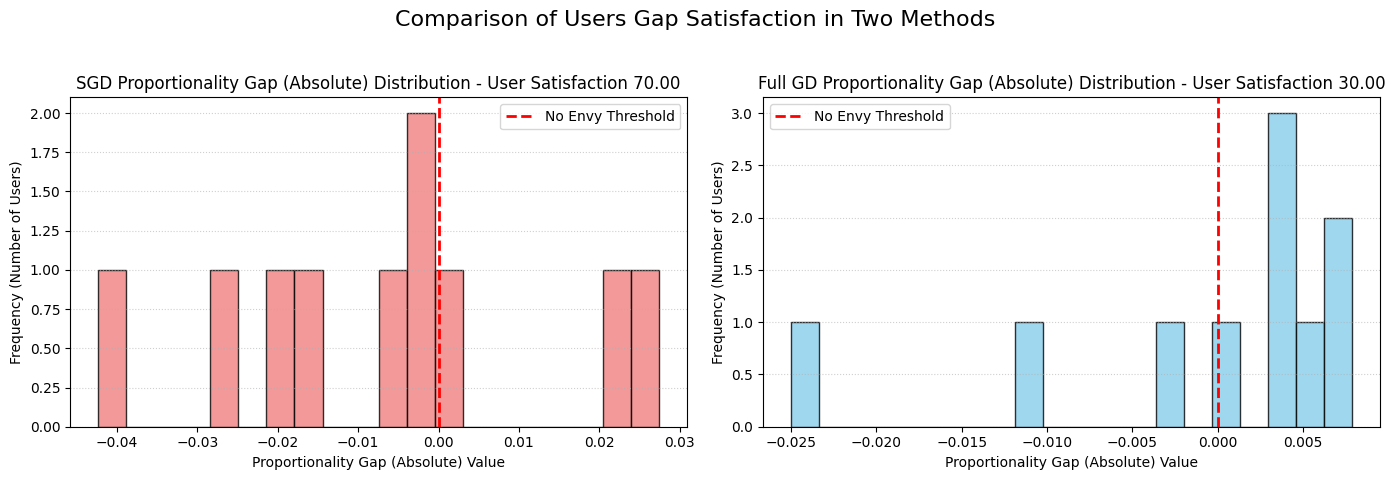

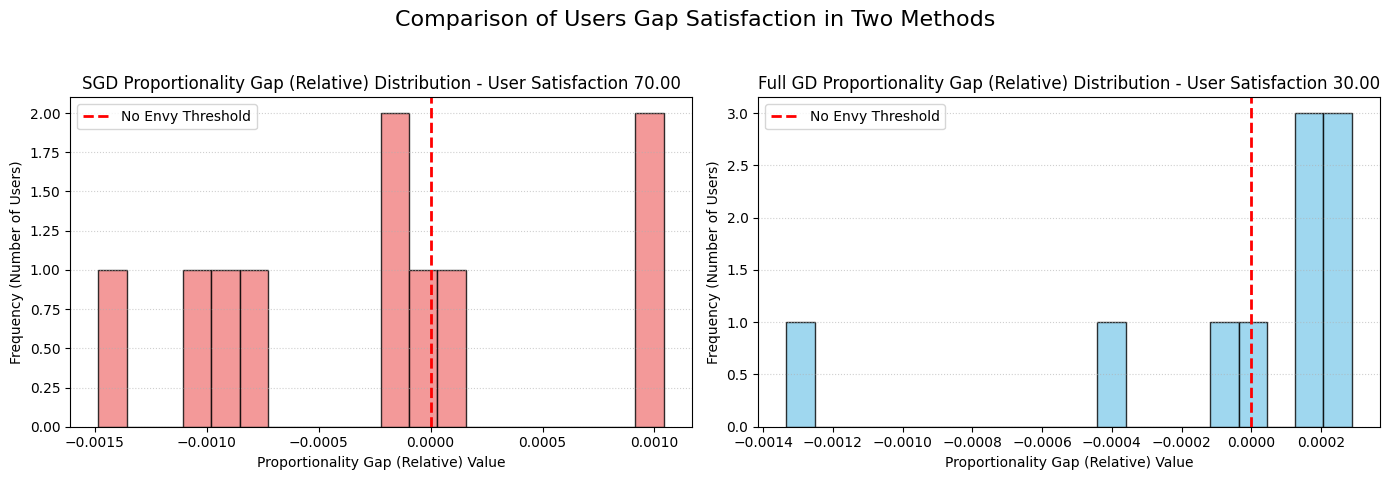

In [ ]:
pro_fair_sgd = proportional_fairness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/constrained_A_absolute_pro.png")

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(constrained_A_data["sgd_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(constrained_A_data["full_run"]["alloc_final"][-1], valuations, constrained_A_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/10users_24items/time_termination/constrained_A_relative_pro.png")

# Data with 50 users and 60 items

## Time termination conditions

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_50u_60i"

# --- Code của bạn bắt đầu từ đây ---
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

✓ Đã tải xong factors. Ma trận Valuations có shape: (50, 60)


In [ ]:
import pickle
import os # Import os module to handle file paths

users_50x60_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/50_users_60_items_data.pkl"
key_name = os.path.splitext(os.path.basename(users_50x60_path))[0]
# Mở file ở chế độ 'rb' (Read Binary)
with open(users_50x60_path, 'rb') as f:
    # Dùng pickle.load() để tái tạo lại đối tượng Python và lưu vào dictionary
    users_50x60_data = pickle.load(f)

print("Đã tải dữ liệu thành công!")

Đã tải dữ liệu thành công!


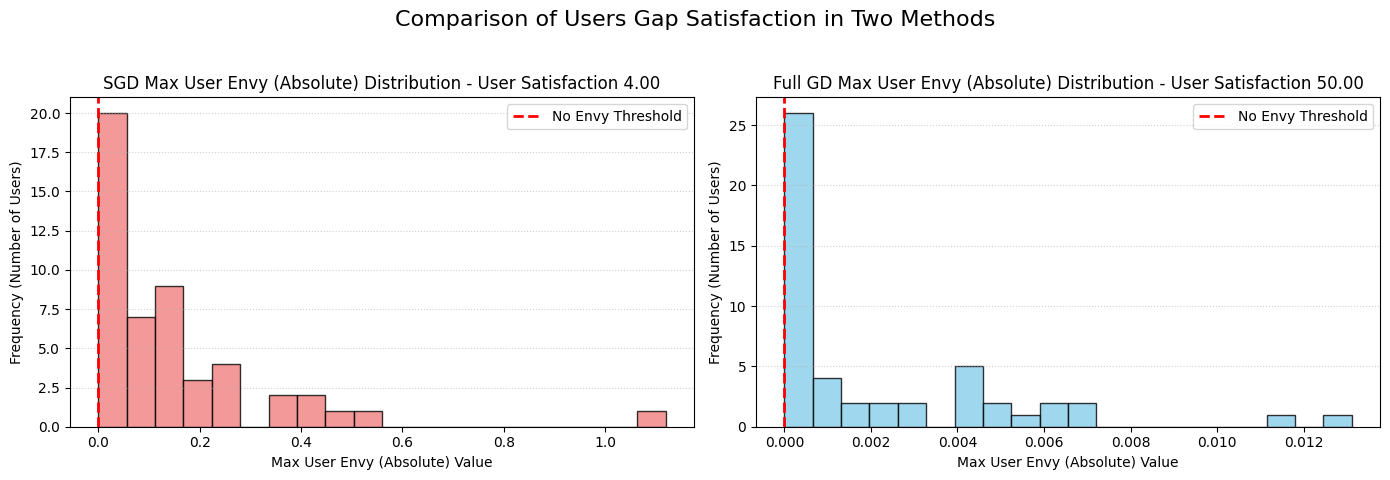

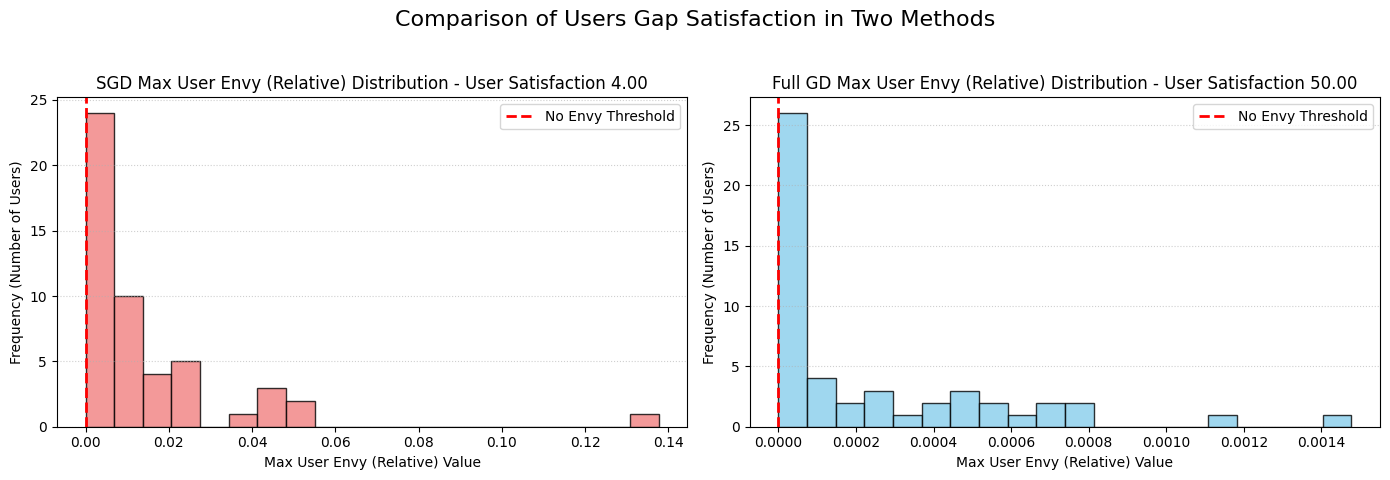

In [ ]:
envy_metrics_sgd = loose_envy_freeness_ces(users_50x60_data["sgd_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
envy_metrics_full = loose_envy_freeness_ces(users_50x60_data["full_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
metrics_histogram(envy_metrics_sgd, envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/50users_60items/time_termination/absolute_envy.png")
plt.show()


# Set relative envy = True, divide by each own_utility_i
envy_metrics_sgd_relative = loose_envy_freeness_ces(users_50x60_data["sgd_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
envy_metrics_full_relative = loose_envy_freeness_ces(users_50x60_data["full_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
metrics_histogram(envy_metrics_sgd_relative, envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/50users_60items/time_termination/relative_envy.png")
plt.show()

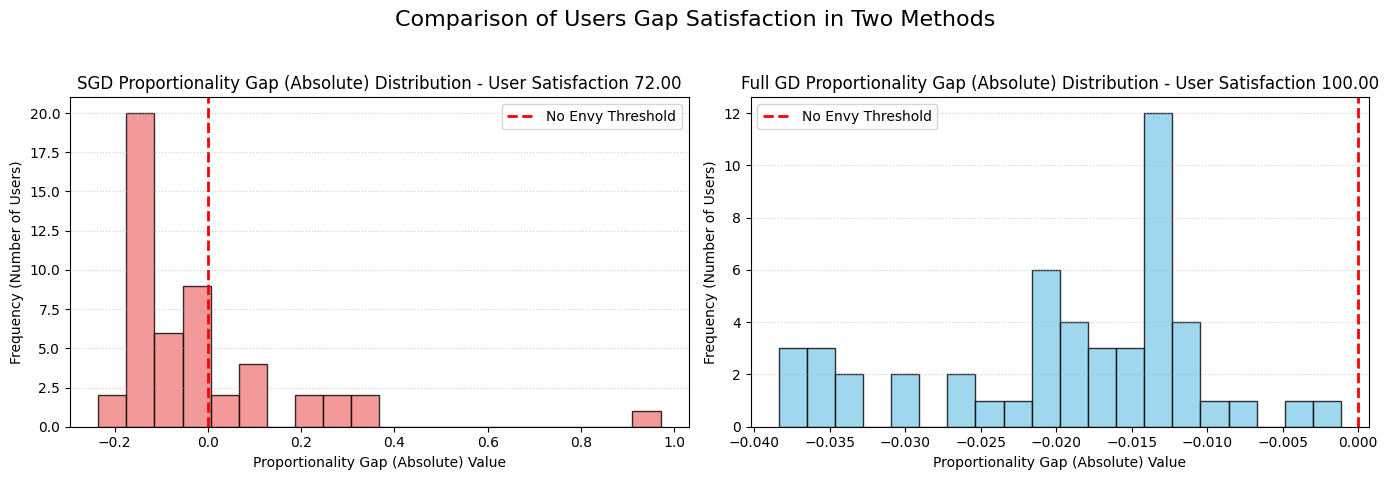

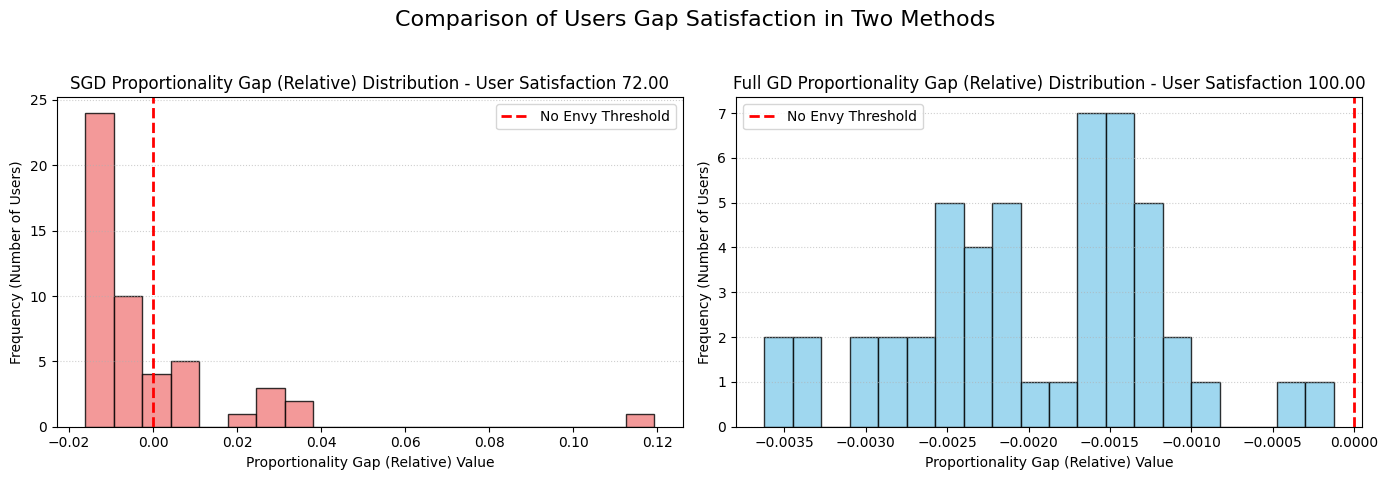

In [ ]:
pro_fair_sgd = proportional_fairness_ces(users_50x60_data["sgd_run"]["alloc_final"][-1], valuations, users_50x60_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(users_50x60_data["full_run"]["alloc_final"][-1], valuations, users_50x60_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/50users_60items/time_termination/absolute_pro.png")
plt.show()

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(users_50x60_data["sgd_run"]["alloc_final"][-1], valuations, users_50x60_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(users_50x60_data["full_run"]["alloc_final"][-1], valuations, users_50x60_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/50users_60items/time_termination/relative_pro.png")
plt.show()


# Data with 300 users and 360 items

## Time termination conditions

In [ ]:
FACTOR_DIR = "/content/drive/MyDrive/EV_charging_project/datasets/valuation_new/val_300u_360i"

# --- Code của bạn bắt đầu từ đây ---
try:
    U = np.load(os.path.join(FACTOR_DIR, "user_factors.npy"))
    P = np.load(os.path.join(FACTOR_DIR, "item_factors.npy"))
    valuations = U @ P.T
    print(f"✓ Đã tải xong factors. Ma trận Valuations có shape: {valuations.shape}")

except Exception as e:
    print(f"⚠️  Lỗi khi tải file: {e}")
    print("Sử dụng ma trận valuations ngẫu nhiên...")
    valuations = np.random.rand(120, 12) + 0.5         # 120 buyers, 12 goods

✓ Đã tải xong factors. Ma trận Valuations có shape: (300, 360)


In [ ]:
import pickle
import os # Import os module to handle file paths

users_300x360_path = "/content/drive/MyDrive/EV_charging_project/experiment_result/time_termination/300_users_360_items_data.pkl"
key_name = os.path.splitext(os.path.basename(users_50x60_path))[0]
# Mở file ở chế độ 'rb' (Read Binary)
with open(users_300x360_path, 'rb') as f:
    # Dùng pickle.load() để tái tạo lại đối tượng Python và lưu vào dictionary
    users_300x360_data = pickle.load(f)

print("Đã tải dữ liệu thành công!")

Đã tải dữ liệu thành công!


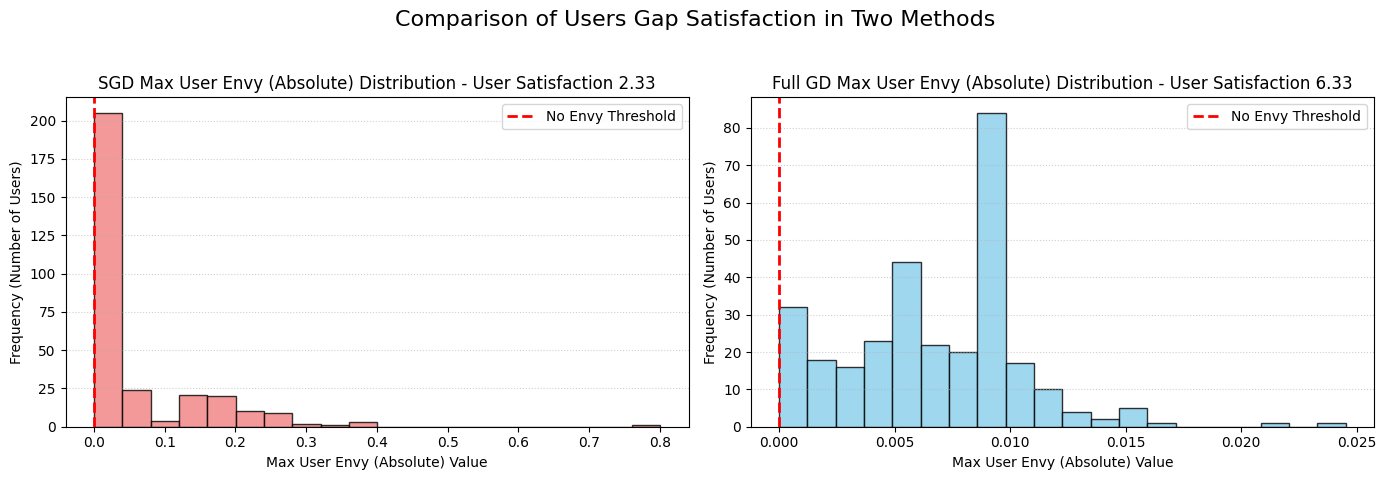

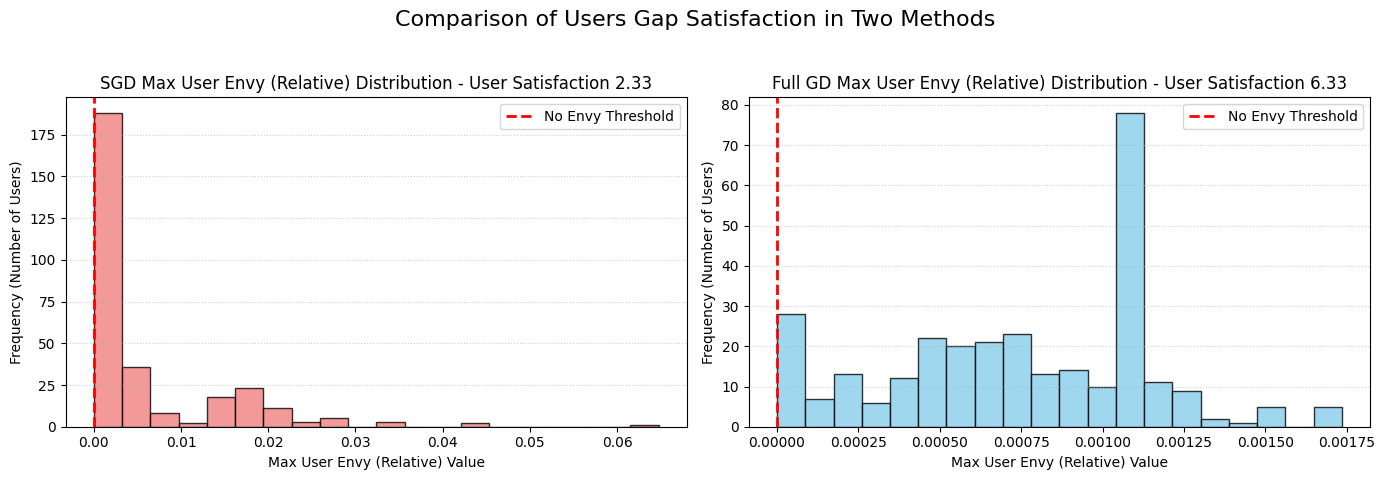

In [ ]:
envy_metrics_sgd = loose_envy_freeness_ces(users_300x360_data["sgd_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
envy_metrics_full = loose_envy_freeness_ces(users_300x360_data["full_run"]["alloc_final"][-1], valuations, m=1) # Adjusted epsilon for absolute envy
metrics_histogram(envy_metrics_sgd, envy_metrics_full, type="Max User Envy (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/300users_360items/time_termination/absolute_envy.png")
plt.show()


# Set relative envy = True, divide by each own_utility_i
envy_metrics_sgd_relative = loose_envy_freeness_ces(users_300x360_data["sgd_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
envy_metrics_full_relative = loose_envy_freeness_ces(users_300x360_data["full_run"]["alloc_final"][-1], valuations, m=1, return_relative_envy=True)
metrics_histogram(envy_metrics_sgd_relative, envy_metrics_full_relative, type="Max User Envy (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/300users_360items/time_termination/relative_envy.png")
plt.show()

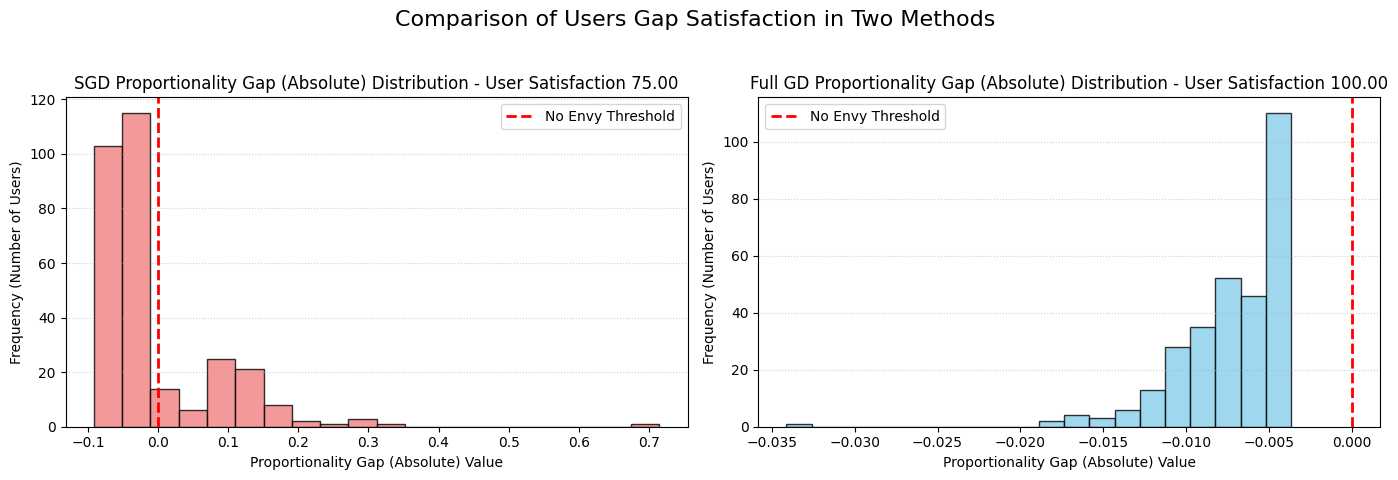

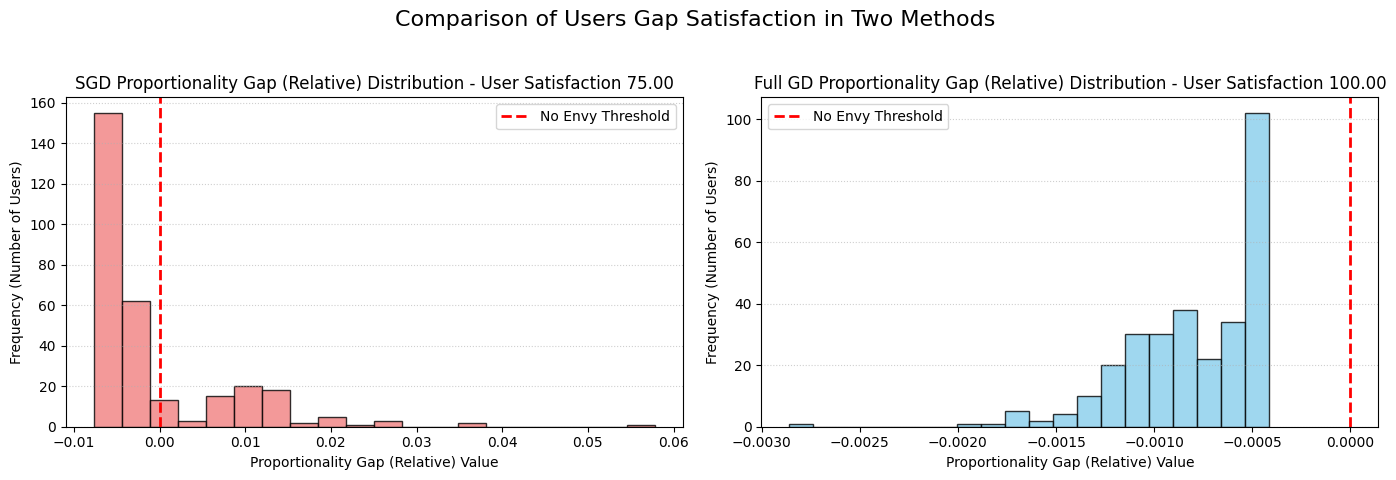

In [ ]:
pro_fair_sgd = proportional_fairness_ces(users_300x360_data["sgd_run"]["alloc_final"][-1], valuations, users_300x360_data["data"]["budgets"])
pro_fair_full = proportional_fairness_ces(users_300x360_data["full_run"]["alloc_final"][-1], valuations, users_300x360_data["data"]["budgets"])
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Absolute)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/300users_360items/time_termination/absolute_pro.png")
plt.show()

# Set relative envy = True, divide by each own_utility_i
pro_fair_sgd = proportional_fairness_ces(users_300x360_data["sgd_run"]["alloc_final"][-1], valuations, users_300x360_data["data"]["budgets"], return_relative_envy=True)
pro_fair_full = proportional_fairness_ces(users_300x360_data["full_run"]["alloc_final"][-1], valuations, users_300x360_data["data"]["budgets"], return_relative_envy=True)
metrics_histogram(pro_fair_sgd , pro_fair_full, type="Proportionality Gap (Relative)")
plt.savefig("/content/drive/MyDrive/EV_charging_project/images/300users_360items/time_termination/relative_pro.png")
plt.show()
